# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Clase 5 — Features de la API de Spotify, clustering aplicado y búsqueda de hiperparámetros con Optuna

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

Este notebook parte de la **base mínima heredada** de las Clases 1–4 (carga, target, feature set, esquema de validación y receta XGBoost, ya cerrados — la justificación de cada decisión vive en los notebooks anteriores) y dedica el cuerpo a tres bloques:

- **Bloque A — features de la API de Spotify**: el plan acordado al cierre de la Clase 4. Una sonda previa ya midió que `duracion_ms` sola suma +0.0034 de AUC CV; acá se construye en serio: la duración con sus derivadas mecánicas, popularidad, antigüedad del tema y metadata menor — cada grupo validado con el protocolo una-decisión-un-número.
- **Bloque B — clustering aplicado** (el no supervisado de las Clases 4–5): por qué el clustering jerárquico no escala al TP (y dónde sí sirve — el dendrograma de nuestros 10 usuarios), el caso de los smart meters de la clase traducido a perfiles horarios, y K-means sobre las ~134 mil canciones como **feature** del pipeline supervisado ("cluster como atributo").
- **Bloque C — Optuna**: reemplazar la grilla exhaustiva de las Clases 2–4 por búsqueda bayesiana (TPE), con la receta heredada encolada como primer trial. Es el "optimizar hiperparámetros como paso final, con el dataset ya cerrado" que recomienda el profesor — por eso va después de A y B.

Cierre de siempre: re-test de la ventana de datos, **una única mirada** a `test_interno`, y submission reentrenada con el 100% de train. Todas las decisiones se toman **solo** contra la CV temporal — nunca contra el leaderboard.

El progreso de toda la corrida se escribe en **`06_progreso_clase5.log`** (corrida completa: ~31 min en esta máquina; el bloque de Optuna, ~20 min, es el más largo).

## Base heredada de las Clases 1–4 (mínima)

Carga, target y derivadas de la Clase 1 (`content_type`, `hora`, `dia_semana`, `artista_top`); esquema de validación de la Clase 2 (`test_interno` = 15% más reciente, intocado hasta el final + CV temporal de ventana expansiva de 4 folds, ventana de train de 24 meses); numéricas de las Clases 3–4 (`gap_min`, `bucket_count_30min`, `pos_en_bucket`, `bucket_count_dia`, `gap_siguiente`, `hora` numérica); matrices ralas y XGBoost de la Clase 4 con su receta re-tuneada (`max_depth=6, eta=0.05, min_child_weight=1, subsample=0.8, colsample_bytree=1.0, gamma=0`, early stopping con tope 600 / paciencia 25). Justificación completa en `01_tp_spotify_clase1_knn.ipynb` … `05_tp_spotify_clase4_xgboost.ipynb` — acá solo el resultado.

Números fijos a superar (documentados en la Clase 4, no se recalculan — pero la referencia de CV sí se **reproduce** más abajo como sanidad): **AUC CV 0.8368**, **`test_interno` 0.8247**, Kaggle público 0.84541.

In [1]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import xgboost as xgb
import optuna

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "../competition_data"
LOG_CLASE5 = "../logs/06_progreso_clase5.log"

# Estilo unico para todos los graficos del notebook (misma paleta validada de la Clase 4).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

open(LOG_CLASE5, "w", encoding="utf-8").close()  # la corrida arranca con el log en blanco


def log_progreso(msg):
    """Mismo sistema de la Clase 4: timestamp, print y linea appendeada al log, para
    seguir la corrida en vivo desde afuera con un tail al archivo."""
    linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(linea, flush=True)
    with open(LOG_CLASE5, "a", encoding="utf-8") as flog:
        flog.write(linea + "\n")


optuna.logging.set_verbosity(optuna.logging.WARNING)  # el log por trial lo escribimos nosotros
log_progreso(f"Clase 5 -- xgboost {xgb.__version__} | optuna {optuna.__version__}")

[19:57:01] Clase 5 -- xgboost 3.2.0 | optuna 4.9.0


In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode", "user_id",
]
DTYPES = {
    "spotify_track_uri": "string", "spotify_episode_uri": "string", "audiobook_uri": "string",
}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

# Derivadas cerradas en la Clase 1.
train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")

train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
log_progreso(f"train cargado: {len(train_raw):,} filas | tasa de abandono {train_raw['target'].mean():.4f}")

[19:57:06] train cargado: 911,344 filas | tasa de abandono 0.2780


In [3]:
n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()

for nombre, df in [("train", df_train), ("test interno", df_test_interno)]:
    print(f"{nombre:<13} {len(df):>7,} filas | {df['ts_dt'].min().date()} -> {df['ts_dt'].max().date()} "
          f"| tasa abandono {df['target'].mean():.4f}")

train         774,642 filas | 2013-10-29 -> 2023-05-26 | tasa abandono 0.2865
test interno  136,702 filas | 2023-05-26 -> 2024-08-31 | tasa abandono 0.2298


In [4]:
# Numericas heredadas (Clases 3-4). Se calculan sobre train+test_interno concatenados para
# que la primera fila de cada bloque respete el historial real del usuario (misma logica de
# las Clases 3-4).
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])

gap = full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
full["gap_min"] = gap.fillna(-1)  # -1 = primera reproduccion de ese usuario en el dataset
full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")
full["pos_en_bucket"] = full.groupby(["user_id", "ts"]).cumcount()
fecha = full["ts_dt"].dt.floor("D")
full["bucket_count_dia"] = full.groupby(["user_id", fecha])["obs_id"].transform("size")
gap_sig = (full.groupby("user_id")["ts_dt"].shift(-1) - full["ts_dt"]).dt.total_seconds() / 60.0
full["gap_siguiente"] = gap_sig.fillna(-1)  # -1 = ultima reproduccion del usuario en el dataset

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso("numericas heredadas listas (gap_min, bucket_count_30min, pos_en_bucket, bucket_count_dia, gap_siguiente)")

[19:57:08] numericas heredadas listas (gap_min, bucket_count_30min, pos_en_bucket, bucket_count_dia, gap_siguiente)


In [5]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
CAT_HEREDADAS = [f for f in TODAS_LAS_FEATURES if f != "hora"] + ["user_id"]
NUM_HEREDADAS = ["gap_min", "bucket_count_30min", "pos_en_bucket", "bucket_count_dia", "gap_siguiente", "hora"]

PARAMS_CLASE4 = dict(max_depth=6, eta=0.05, min_child_weight=1, subsample=0.8, colsample_bytree=1.0, gamma=0.0)
BASE_PARAMS_XGB = dict(objective="binary:logistic", eval_metric="auc", seed=RANDOM_STATE)
NUM_BOOST_MAX, EARLY_STOP, N_FOLDS = 600, 25, 4
VENTANA_HEREDADA = 24

AUC_CLASE4_CV, AUC_CLASE4_TEST, SCORE_CLASE4_KAGGLE = 0.8368, 0.8247, 0.84541


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def make_expanding_folds(df, n_folds=4):
    """Folds temporales de ventana expansiva. df debe venir ordenado cronologicamente."""
    n = len(df)
    bordes = np.linspace(0, n, n_folds + 2, dtype=int)
    folds = []
    for i in range(1, n_folds + 1):
        idx_train = np.arange(0, bordes[i])
        idx_val = np.arange(bordes[i], bordes[i + 1])
        if len(idx_val) > 0 and len(idx_train) > 0:
            folds.append((idx_train, idx_val))
    return folds


def limpiar_nombres_columnas(cols):
    """XGBoost rechaza nombres de columna con '[', ']' o '<' (aparecen en nombres de artistas).
    Dedupe defensivo por si dos nombres distintos colisionan tras la limpieza."""
    limpios = [re.sub(r"[\[\]<]", "_", str(c)) for c in cols]
    vistos, out = {}, []
    for c in limpios:
        if c in vistos:
            vistos[c] += 1
            out.append(f"{c}__dup{vistos[c]}")
        else:
            vistos[c] = 0
            out.append(c)
    return out


def build_sparse_matrix(df, cat_features, num_features):
    cat_features = list(cat_features)
    # columns=cat_features es necesario: por default get_dummies deja pasar sin codificar
    # las bool/int (gotcha documentado en la Clase 4). Los NaN de las numericas quedan
    # almacenados explicitamente en la matriz rala y XGBoost los rutea como missing
    # (Sparsity Aware Split Finding, Clase 4).
    cat_dummies = pd.get_dummies(df[cat_features], columns=cat_features, dummy_na=True, sparse=True)
    X_cat = sp.csr_matrix(cat_dummies.sparse.to_coo())
    X_num = sp.csr_matrix(df[list(num_features)].astype(float).values)
    X = sp.hstack([X_cat, X_num], format="csr")
    feature_names = limpiar_nombres_columnas(list(cat_dummies.columns.astype(str)) + list(num_features))
    y = df["target"].to_numpy()
    return X, y, feature_names


def evaluar_cv(cat_feats, num_feats, params, ventana=VENTANA_HEREDADA, etiqueta="", df=None):
    """CV temporal completa (4 folds de ventana expansiva, train de cada fold filtrado a la
    ventana) para un set de features y una receta. Devuelve (auc_promedio, aucs_por_fold,
    rondas_promedio, n_columnas). df=None se resuelve a df_train ADENTRO de la funcion:
    un default 'df=df_train' se evaluaria una sola vez y quedaria apuntando a la version
    vieja cuando df_train se reasigna (gotcha documentado en la Clase 4)."""
    if df is None:
        df = df_train
    t0 = time.time()
    X, y, nombres = build_sparse_matrix(df, cat_feats, num_feats)
    aucs, rondas = [], []
    for idx_tr, idx_val in make_expanding_folds(df, n_folds=N_FOLDS):
        if ventana is not None:
            corte = df["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_tr = idx_tr[(df["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        dtr = xgb.DMatrix(X[idx_tr], label=y[idx_tr], feature_names=nombres)
        dva = xgb.DMatrix(X[idx_val], label=y[idx_val], feature_names=nombres)
        bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                        evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
        aucs.append(float(bst.best_score))
        rondas.append(bst.best_iteration + 1)
    auc = float(np.mean(aucs))
    if etiqueta:
        detalle = " ".join(f"{a:.4f}" for a in aucs)
        log_progreso(f"{etiqueta:<52s} -> AUC CV {auc:.4f} | folds [{detalle}] | rondas prom {np.mean(rondas):3.0f} | {time.time() - t0:4.0f}s")
    return auc, aucs, float(np.mean(rondas)), X.shape[1]


print(f"CAT_HEREDADAS ({len(CAT_HEREDADAS)}):", CAT_HEREDADAS)
print(f"NUM_HEREDADAS ({len(NUM_HEREDADAS)}):", NUM_HEREDADAS)
print(f"Receta heredada: {PARAMS_CLASE4}")
print(f"A superar -- AUC CV Clase 4: {AUC_CLASE4_CV:.4f} | test_interno: {AUC_CLASE4_TEST:.4f}")

CAT_HEREDADAS (9): ['platform_family', 'conn_country', 'shuffle', 'offline', 'incognito_mode', 'dia_semana', 'content_type', 'artista_top', 'user_id']
NUM_HEREDADAS (6): ['gap_min', 'bucket_count_30min', 'pos_en_bucket', 'bucket_count_dia', 'gap_siguiente', 'hora']
Receta heredada: {'max_depth': 6, 'eta': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'gamma': 0.0}
A superar -- AUC CV Clase 4: 0.8368 | test_interno: 0.8247


### Sanidad: reproducir la referencia de la Clase 4 antes de tocar nada

Todo el notebook compara contra la CV heredada. Si esta corrida no reproduce el **0.8368** de la Clase 4 con el mismo feature set, la misma receta y la misma semilla, ninguna comparación posterior vale — mejor enterarse ahora, en el minuto 2, que después de dos horas. (La sonda previa de la API ya lo reprodujo exacto; esto re-verifica que la herencia quedó bien copiada acá.)

In [6]:
log_progreso("=== Sanidad: reproducir la referencia de la Clase 4 ===")
AUC_REF, _, RONDAS_REF, COLS_REF = evaluar_cv(CAT_HEREDADAS, NUM_HEREDADAS, PARAMS_CLASE4,
                                              etiqueta="referencia heredada (esperado 0.8368)")
if abs(AUC_REF - AUC_CLASE4_CV) > 0.0005:
    log_progreso(f"ATENCION: la referencia ({AUC_REF:.4f}) no reproduce el {AUC_CLASE4_CV:.4f} esperado -- "
                 "revisar la herencia antes de confiar en las comparaciones de este notebook")
else:
    log_progreso(f"sanidad OK: referencia {AUC_REF:.4f} ({COLS_REF} columnas)")

[19:57:08] === Sanidad: reproducir la referencia de la Clase 4 ===
[19:57:43] referencia heredada (esperado 0.8368)                -> AUC CV 0.8368 | folds [0.7825 0.8381 0.8855 0.8410] | rondas prom 222 |   35s
[19:57:43] sanidad OK: referencia 0.8368 (141 columnas)


## Bloque A — Features de la API de Spotify

`spotify_api_data.zip` (metadata cruda por track/episode, uso opcional autorizado) ya está parseado y cacheado en `competition_data/api_features.pkl`: **135.655 URIs** (133.959 tracks + 1.696 episodes) con `duration_ms`, `popularity`, `explicit`, `release_date`, `album_total_tracks`, `track_number`. Cobertura verificada: ~99.9% de las filas de train. Es información **por canción**, no por reproducción — el join es por URI.

**El matiz honesto, medido en la sonda y verificado de nuevo abajo:** la hipótesis mecánica "si el tema entero dura < 30 s, escucharlo 30 s es imposible ⇒ `target=1` por definición" dio ~93%, no ~100%. La metadata de la API es la *actual*: la versión del tema al momento de la reproducción pudo ser otra (remasters, re-releases, ediciones). La señal es fuerte pero no es un oráculo — y eso también aplica a `release_date` (puede ser *posterior* a la reproducción; esas antigüedades negativas se dejan, son información, no error).

Candidatas, en orden de evaluación (acumulativo: cada grupo se prueba sobre lo ya adoptado, y solo queda si el AUC CV **sube estrictamente**):

1. **`duracion_ms`** cruda — la sonda ya midió +0.0034; acá se re-mide dentro del notebook. El 0.1% sin metadata queda como NaN y XGBoost lo rutea (Clase 4).
2. **Mecánicas de la definición del target**: `dur_menor_30s` (la bandera de arriba) y `carga_bucket` = `bucket_count_30min × duracion_ms / 30 min` — cuántos "bloques equivalentes" de reproducción completa reclama el bloque real; un valor > 1 es físicamente imposible sin cortes. Es una interacción explícita entre nuestra señal más fuerte y la duración: la Clase 3 dijo que los árboles arman interacciones "de alguna manera" con splits anidados — esta relación es aritmética, se la damos hecha.
3. **`popularity`** (0–100, actual; episodes no la tienen → missing).
4. **`antiguedad_dias`** = `ts` − `release_date`: qué tan viejo era el tema al escucharlo. `release_date` viene con precisión variable (año / año-mes / fecha exacta) → se paddea al primer día del período.
5. **Metadata menor**: `explicit`, `track_number`, `album_total_tracks` — sin gran hipótesis; se prueban juntas como grupo de bajo costo.

In [7]:
api = pd.read_pickle(f"{DATA_DIR}/api_features.pkl")
api_idx = api.set_index("uri")
log_progreso(f"=== Bloque A: features de la API ===")
log_progreso(f"api_features.pkl: {len(api):,} URIs ({(api['tipo'] == 'track').sum():,} tracks, "
             f"{(api['tipo'] == 'episode').sum():,} episodes)")


def agregar_columnas_api(df):
    """Mapea la metadata de la API por URI (track o episode) y construye las derivadas.
    Requiere ts_dt y bucket_count_30min ya calculados en df. Los URIs sin metadata quedan
    NaN en todo (XGBoost los rutea como missing)."""
    df["uri"] = df["spotify_track_uri"].fillna(df["spotify_episode_uri"])
    df["duracion_ms"] = df["uri"].map(api_idx["duration_ms"])
    df["popularity"] = df["uri"].map(api_idx["popularity"])
    df["explicit_num"] = df["uri"].map(api_idx["explicit"].astype(float))
    df["track_number"] = df["uri"].map(api_idx["track_number"])
    df["album_total_tracks"] = df["uri"].map(api_idx["album_total_tracks"])

    # release_date con precision variable: 'yyyy', 'yyyy-mm' o 'yyyy-mm-dd' -> paddear
    rel = df["uri"].map(api_idx["release_date"]).astype("string")
    rel = rel.where(rel.str.len() != 4, rel + "-01-01")
    rel = rel.where(rel.str.len() != 7, rel + "-01")
    release_dt = pd.to_datetime(rel, errors="coerce", utc=True)
    df["antiguedad_dias"] = (df["ts_dt"] - release_dt).dt.days.astype(float)

    dur = df["duracion_ms"]
    df["dur_menor_30s"] = np.where(dur.isna(), np.nan, (dur < 30000).astype(float))
    df["carga_bucket"] = df["bucket_count_30min"] * dur / (30 * 60 * 1000)
    return df


full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full = agregar_columnas_api(full)
df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

cobertura = full["duracion_ms"].notna().mean()
por_tipo = full.groupby("content_type")["duracion_ms"].apply(lambda s: s.notna().mean())
log_progreso(f"cobertura de la API: {cobertura:.1%} de las filas | por tipo: "
             + " | ".join(f"{t} {v:.1%}" for t, v in por_tipo.items()))

cortas = full[full["duracion_ms"] < 30000]
log_progreso(f"sanidad mecanica: {len(cortas):,} filas con duracion<30s -> target=1 en {cortas['target'].mean():.1%} "
             "(no ~100%: metadata actual vs. version historica del tema)")

neg = (df_train["antiguedad_dias"] < 0).mean()
log_progreso(f"antiguedad negativa (release posterior a la escucha, se deja): {neg:.2%} de las filas de train")
print(df_train[["duracion_ms", "dur_menor_30s", "carga_bucket", "popularity", "antiguedad_dias"]].describe().round(2).to_string())

[19:57:43] === Bloque A: features de la API ===
[19:57:43] api_features.pkl: 135,655 URIs (133,959 tracks, 1,696 episodes)
[19:57:46] cobertura de la API: 99.9% de las filas | por tipo: episode 82.7% | track 100.0%
[19:57:46] sanidad mecanica: 2,040 filas con duracion<30s -> target=1 en 93.2% (no ~100%: metadata actual vs. version historica del tema)
[19:57:46] antiguedad negativa (release posterior a la escucha, se deja): 0.02% de las filas de train
       duracion_ms  dur_menor_30s  carga_bucket  popularity  antiguedad_dias
count    774129.00      774129.00     774129.00   771335.00        774129.00
mean     237631.95           0.00          2.41       34.57          4911.71
std      192703.36           0.05          4.63       28.40         11425.93
min           0.00           0.00          0.00        0.00         -2307.00
25%      185092.00           0.00          0.80        1.00           631.00
50%      220792.00           0.00          1.18       35.00          2779.00
75%   

In [8]:
GRUPOS_API = [
    ("duracion_ms",       ["duracion_ms"]),
    ("mecanicas target",  ["dur_menor_30s", "carga_bucket"]),
    ("popularity",        ["popularity"]),
    ("antiguedad_dias",   ["antiguedad_dias"]),
    ("metadata menor",    ["explicit_num", "track_number", "album_total_tracks"]),
]

log_progreso(f"evaluacion acumulativa de la API (referencia {AUC_REF:.4f}):")
num_actual = list(NUM_HEREDADAS)
auc_actual, rondas_actual = AUC_REF, RONDAS_REF
historial_A = []
for etiqueta, cols in GRUPOS_API:
    auc, _, rondas, _ = evaluar_cv(CAT_HEREDADAS, num_actual + cols, PARAMS_CLASE4,
                                   etiqueta=f"+ {etiqueta} ({', '.join(cols)})")
    adoptado = auc > auc_actual
    historial_A.append({"grupo": etiqueta, "auc_cv": round(auc, 4),
                        "delta": round(auc - auc_actual, 4), "adoptado": adoptado})
    log_progreso(f"    {'ADOPTADO' if adoptado else 'rechazado'}: {etiqueta} ({auc - auc_actual:+.4f})")
    if adoptado:
        num_actual = num_actual + cols
        auc_actual, rondas_actual = auc, rondas

NUM_API = num_actual
AUC_REF_A, RONDAS_REF_A = auc_actual, rondas_actual

print("\nResumen Bloque A (cada delta es contra la referencia acumulada al momento de probar):")
print(pd.DataFrame(historial_A).to_string(index=False))
log_progreso(f"cierre Bloque A: AUC CV {AUC_REF_A:.4f} ({AUC_REF_A - AUC_REF:+.4f} vs. herencia) | "
             f"numericas: {len(NUM_API)} ({[c for c in NUM_API if c not in NUM_HEREDADAS]} adoptadas)")

[19:57:47] evaluacion acumulativa de la API (referencia 0.8368):
[19:58:30] + duracion_ms (duracion_ms)                          -> AUC CV 0.8402 | folds [0.7861 0.8417 0.8883 0.8445] | rondas prom 244 |   43s
[19:58:30]     ADOPTADO: duracion_ms (+0.0034)
[19:59:06] + mecanicas target (dur_menor_30s, carga_bucket)     -> AUC CV 0.8405 | folds [0.7844 0.8424 0.8894 0.8456] | rondas prom 198 |   36s
[19:59:06]     ADOPTADO: mecanicas target (+0.0003)
[19:59:43] + popularity (popularity)                            -> AUC CV 0.8409 | folds [0.7855 0.8428 0.8897 0.8456] | rondas prom 194 |   37s
[19:59:43]     ADOPTADO: popularity (+0.0004)
[20:00:27] + antiguedad_dias (antiguedad_dias)                  -> AUC CV 0.8415 | folds [0.7870 0.8430 0.8901 0.8457] | rondas prom 254 |   43s
[20:00:27]     ADOPTADO: antiguedad_dias (+0.0006)
[20:01:07] + metadata menor (explicit_num, track_number, album_total_tracks) -> AUC CV 0.8419 | folds [0.7871 0.8431 0.8911 0.8460] | rondas prom 263 |   40s
[

**Resultado: los cinco grupos quedaron adoptados — AUC CV 0.8368 → 0.8419 (+0.0051).** Cada delta es contra la referencia acumulada al momento de probar (protocolo acumulativo — por eso el orden importa y no es inocente: `duracion_ms` va primera porque la sonda ya la había validado sola; las mecánicas después porque derivan de ella; los grupos de hipótesis más débil al final, donde deben ganarse el lugar contra una vara ya más alta):

| Grupo | AUC CV | Δ |
|---|---|---|
| + `duracion_ms` | 0.8402 | **+0.0034** |
| + mecánicas (`dur_menor_30s`, `carga_bucket`) | 0.8405 | +0.0003 |
| + `popularity` | 0.8409 | +0.0004 |
| + `antiguedad_dias` | 0.8415 | +0.0006 |
| + metadata menor (`explicit_num`, `track_number`, `album_total_tracks`) | 0.8419 | +0.0004 |

`duracion_ms` sola aporta dos tercios del salto del bloque — una columna de metadata vale más que todo el tuneo de hiperparámetros de la Clase 4 junto (+0.003 entre dos grillas de 48 combos y el refinamiento). Las otras siete columnas suman de a poco pero suman (+0.0017 entre todas), y en ningún paso hubo retroceso sostenido de folds: la regla de adopción estricta (un empate no paga el costo de complejidad) no tuvo que rechazar nada.

Nota honesta que queda documentada para el informe: `dur_menor_30s` y `carga_bucket` pertenecen a la misma familia "estructural" que `bucket_count_30min` — explotan la definición del target y la mecánica del bloque de 30 minutos, más que comportamiento profundo del usuario. Mismo estándar de honestidad que fijó el profesor ("un poco de trampa, pero sirve"), misma legitimidad batch: todo se calcula de metadata disponible en el test estático de Kaggle, sin tocar ningún target. Las dos terminaron dentro del top-15 de importancias del modelo final (ver más abajo).

## Bloque B — Clustering aplicado (el no supervisado de las Clases 4–5)

Lo que dio la Clase 5: **clustering jerárquico aglomerativo** (bottom-up: cada observación arranca como su propio cluster y se van fusionando los dos más cercanos), el **dendrograma** como resultado (el eje Y es la distancia a la que se fusionan — el eje X no significa nada), las **funciones de enlace** para medir distancia entre clusters con más de un punto (*single* = mínimo par a par, *complete* = máximo, *average* = promedio; complete tiende a clusters balanceados, single a "encadenar" observaciones sueltas; la distancia entre centroides no se usa porque puede romper la monotonía del dendrograma), y elegir K **a posteriori** cortando el dendrograma a una altura.

El costo que la clase remarcó con una demo en vivo: el paso 1 es la **matriz de distancias completa, O(n²)** — con 1 millón de filas por 20 columnas, K-means corre en segundos y el jerárquico pide ~4 TB de RAM y pincha. Y la advertencia conceptual: en no supervisado **no hay conjunto de validación** — no existe "el cluster correcto", solo robustez y utilidad de dominio.

Cómo lo bajamos al TP, en tres pasos:

1. **Verificar el pinchazo con nuestra aritmética** (sin correrlo): ¿cuánta RAM pediría la matriz de distancias de nuestro `df_train`?
2. **El caso de los smart meters, traducido**: en la clase, 1.500 medidores × perfil de consumo de 48 medias horas, z-score por fila para comparar *formas* y no niveles. Nuestro análogo directo: **10 usuarios × perfil de actividad de 24 horas**. Y acá aparece la vuelta linda: el jerárquico que es inviable con 774 mil filas es la herramienta *perfecta* para 10 usuarios — dendrograma completo, exacto y legible.
3. **K-means como feature del pipeline supervisado** ("cluster como atributo", la aplicación que la Clase 4 dejó anotada): clusterizar las **canciones** por su metadata de la API y darle el ID de cluster al modelo como categórica. Acá se disuelve el problema de validación del no supervisado: el cluster no es un fin, es un medio — y la vara es la misma CV supervisada de siempre (¿sube el AUC o no?).

In [9]:
n_obs = len(df_train)
pares = n_obs * (n_obs - 1) / 2
tb = pares * 8 / 1e12  # float64
log_progreso("=== Bloque B: clustering aplicado ===")
log_progreso(f"jerarquico a escala TP: {n_obs:,} filas -> {pares:,.0f} distancias unicas "
             f"~ {tb:,.1f} TB de RAM solo para la matriz -- inviable, tal cual pincho en la demo de la clase")
print(f"K-means, en cambio, calcula K centroides x {n_obs:,} filas por iteracion -- corre en segundos (lo usamos abajo).")

[20:01:07] === Bloque B: clustering aplicado ===
[20:01:07] jerarquico a escala TP: 774,642 filas -> 300,034,726,761 distancias unicas ~ 2.4 TB de RAM solo para la matriz -- inviable, tal cual pincho en la demo de la clase
K-means, en cambio, calcula K centroides x 774,642 filas por iteracion -- corre en segundos (lo usamos abajo).


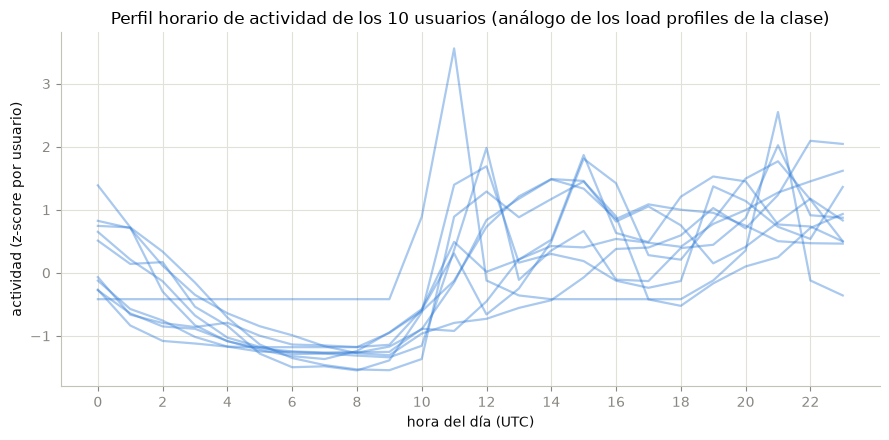

[20:01:08] perfiles horarios calculados: 10 usuarios x 24 horas


In [10]:
# Caso smart-meters traducido: cada usuario ~ un medidor; su "consumo" ~ cuantas
# reproducciones hace en cada hora del dia. z-score POR FILA (por usuario), como la clase:
# compara FORMAS de perfil, no niveles de actividad (un usuario heavy y uno liviano con el
# mismo patron horario deben quedar juntos).
perfil = df_train.groupby(["user_id", "hora"]).size().unstack(fill_value=0)
std_fila = perfil.std(axis=1).replace(0, 1.0)
perfil_z = perfil.sub(perfil.mean(axis=1), axis=0).div(std_fila, axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
for _, fila in perfil_z.iterrows():
    ax.plot(fila.index, fila.values, color=C_AZUL, alpha=0.4, lw=1.6)
ax.set_xlabel("hora del día (UTC)")
ax.set_ylabel("actividad (z-score por usuario)")
ax.set_title("Perfil horario de actividad de los 10 usuarios (análogo de los load profiles de la clase)")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()
log_progreso(f"perfiles horarios calculados: {perfil_z.shape[0]} usuarios x {perfil_z.shape[1]} horas")

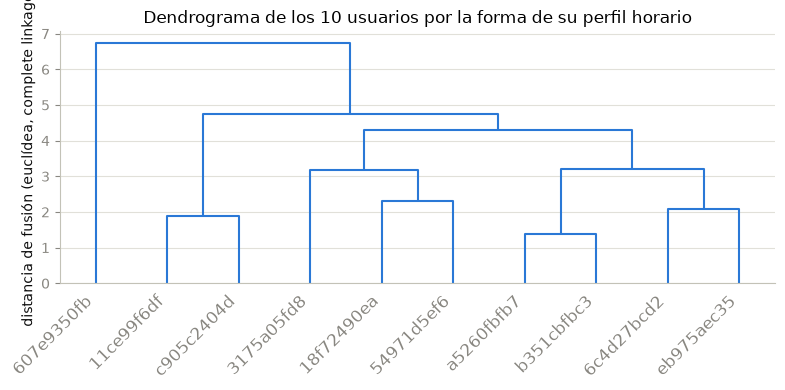

[20:01:08] dendrograma de usuarios generado (jerarquico SI es viable con N=10)


In [11]:
# Con N=10 el jerarquico es exacto y barato: matriz de distancias de 45 pares.
# Complete linkage (el que la clase muestra como el de clusters mas balanceados).
Z = linkage(perfil_z.values, method="complete", metric="euclidean")

fig, ax = plt.subplots(figsize=(8, 4))
dendrogram(Z, labels=[str(u)[:10] for u in perfil_z.index], ax=ax,
           color_threshold=0, above_threshold_color=C_AZUL)
ax.set_ylabel("distancia de fusión (euclídea, complete linkage)")
ax.set_title("Dendrograma de los 10 usuarios por la forma de su perfil horario")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
log_progreso("dendrograma de usuarios generado (jerarquico SI es viable con N=10)")

**Lectura.** La maraña de perfiles solapados de la primera figura es exactamente lo que la clase mostró con los 1.500 medidores antes de clusterizar; el dendrograma la ordena: la altura de cada fusión (eje Y) dice qué tan distintas son las *formas* de actividad horaria de los usuarios — fusiones bajas = rutinas horarias parecidas, la fusión final más alta = el usuario de patrón más atípico. Es la misma herramienta que con 774 mil filas pediría terabytes, aplicada donde corresponde: N=10.

**Honestidad sobre su rol:** esto es EDA/insumo del informe (una figura interpretable sobre quiénes son nuestros 10 usuarios), **no una feature**. No lo evaluamos en la CV a propósito: `user_id` ya entra one-hot al modelo — 10 categorías que le dan flexibilidad total por usuario — y cualquier "cluster de usuarios" sería una versión comprimida (más pobre) de información que el modelo ya tiene entera. Agregar la columna solo para verla rechazada sería gastar una evaluación en algo estructuralmente redundante.

### K-means sobre canciones: cluster como atributo

Dónde sí hay cardinalidad que comprimir: **~84 mil canciones distintas** en `df_train` (y 135 mil URIs en la API). El one-hot sin tope de canciones ya se probó dos veces —Clase 3 con el árbol, Clase 4 con XGBoost— y nunca superó la referencia: 100 mil columnas que la matriz rala banca en memoria pero que no pagan en AUC. El cluster ataca lo mismo desde el otro extremo: en vez de una columna por canción, **K grupos de canciones** definidos por su metadata intrínseca de la API (`log(duración)`, `popularity`, año de release, `explicit`, `track_number`, `album_total_tracks`).

Decisiones, cada una con su porqué:

- **Estandarizar antes de clusterizar** (z-score por columna): K-means es sensible a escala igual que KNN — sin esto, `duration_ms` (cientos de miles) dominaría toda la distancia. Es la advertencia central de la clase (el ejemplo de Boston clusterizando por las dos variables de mayor varianza). La duración además entra en log (Clase 3: colas largas).
- **Imputación por mediana del train** para los pocos NaN: a diferencia de XGBoost, K-means no rutea missing — hay que decidir, y queda documentado. Las canciones **sin metadata de API** directamente no entran al espacio: reciben la categoría propia `sin_api` (la lección de missing de las Clases 3–4: el faltante como categoría, no como cero mentiroso).
- **Fit solo con las canciones de `df_train`**; todo lo demás (canciones nuevas del `test_interno` y del test de Kaggle) se asigna con `predict` sobre centroides ya congelados. La metadata no toca el target, pero mantener la disciplina de "nada del futuro entra a un fit" es gratis.
- **Método del codo para mirar la estructura** (la clase: subjetivo, "a veces no hay codo"), pero la decisión final de K no la toma el ojo: se prueban **K=5 y K=10 contra la CV supervisada** — en este pipeline el cluster es una feature, y las features se juzgan por el AUC, como todo.
- **Interpretación con el truco del profesor**: un árbol de decisión chico con el cluster como pseudo-target, para ver qué variables definen los grupos — más la tabla de centroides des-estandarizados.

[20:01:08] matriz de canciones para K-means: 114,276 tracks x 6 features (solo URIs vistas en df_train)
[20:01:20] codo K-means calculado (K=2..12)


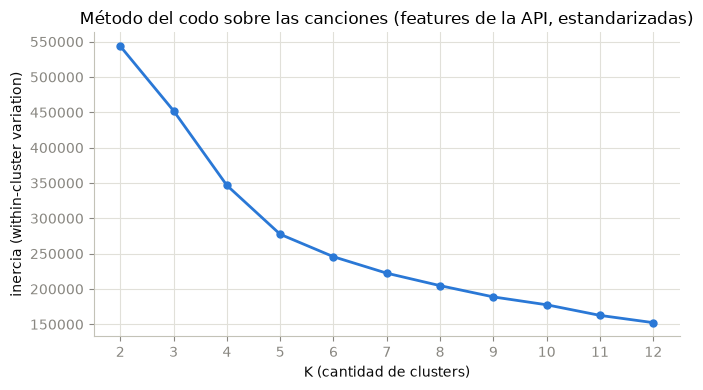

In [12]:
FEATS_TRACK = ["log_duracion", "popularity", "release_year", "explicit_num", "track_number", "album_total_tracks"]


def features_de_tracks(tabla_api):
    """Deriva las features de clustering desde la metadata cruda de la API."""
    t = tabla_api.copy()
    t["log_duracion"] = np.log1p(t["duration_ms"])
    rel = t["release_date"].astype("string")
    t["release_year"] = pd.to_numeric(rel.str[:4], errors="coerce")
    t["explicit_num"] = t["explicit"].astype(float)
    return t[FEATS_TRACK]


uris_train = pd.Index(df_train["uri"].dropna().unique())
M_train_raw = features_de_tracks(api_idx.loc[api_idx.index.intersection(uris_train)])
MEDIANAS_TRACK = M_train_raw.median()
M_train = M_train_raw.fillna(MEDIANAS_TRACK)
scaler_tracks = StandardScaler().fit(M_train)
M_train_z = scaler_tracks.transform(M_train)
log_progreso(f"matriz de canciones para K-means: {M_train_z.shape[0]:,} tracks x {len(FEATS_TRACK)} features "
             "(solo URIs vistas en df_train)")

KS = list(range(2, 13))
inercias = []
for k in KS:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(M_train_z)
    inercias.append(km.inertia_)
log_progreso("codo K-means calculado (K=2..12)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(KS, inercias, color=C_AZUL, lw=2, marker="o", markersize=5)
ax.set_xlabel("K (cantidad de clusters)")
ax.set_ylabel("inercia (within-cluster variation)")
ax.set_title("Método del codo sobre las canciones (features de la API, estandarizadas)")
ax.set_xticks(KS)
plt.tight_layout()
plt.show()

In [13]:
# Fit de los dos K candidatos con las canciones de df_train; prediccion para TODAS las URIs
# de la API (los centroides quedan congelados -- las canciones futuras solo se asignan).
M_all = features_de_tracks(api_idx).fillna(MEDIANAS_TRACK)
M_all_z = scaler_tracks.transform(M_all)

KMEANS_MODELS, CLUSTER_MAPS = {}, {}
for k in (5, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(M_train_z)
    KMEANS_MODELS[k] = km
    CLUSTER_MAPS[k] = pd.Series([f"c{c}" for c in km.predict(M_all_z)], index=M_all.index)
    tam = pd.Series(km.labels_).value_counts().sort_index()
    log_progreso(f"K-means K={k}: tracks de train por cluster {tam.to_list()}")

full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
for k in (5, 10):
    full[f"track_cluster{k}"] = full["uri"].map(CLUSTER_MAPS[k]).fillna("sin_api")
df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

print(df_train["track_cluster5"].value_counts().to_string())

[20:01:22] K-means K=5: tracks de train por cluster [59054, 7324, 5750, 85, 42063]
[20:01:24] K-means K=10: tracks de train por cluster [13663, 12317, 85, 34110, 7319, 26017, 17887, 31, 2460, 387]
track_cluster5
c4         403798
c0         296275
c1          52952
c2          20954
sin_api       513
c3            150


In [14]:
log_progreso(f"cluster como atributo, contra la CV (referencia {AUC_REF_A:.4f}):")
resultados_B = {}
for k in (5, 10):
    auc, _, rondas, _ = evaluar_cv(CAT_HEREDADAS + [f"track_cluster{k}"], NUM_API, PARAMS_CLASE4,
                                   etiqueta=f"+ track_cluster K={k}")
    resultados_B[k] = (auc, rondas)

mejor_k = max(resultados_B, key=lambda k: resultados_B[k][0])
if resultados_B[mejor_k][0] > AUC_REF_A:
    K_ADOPTADO = mejor_k
    CAT_FINAL_5 = CAT_HEREDADAS + [f"track_cluster{mejor_k}"]
    AUC_REF_B, RONDAS_REF_B = resultados_B[mejor_k]
    log_progreso(f"    ADOPTADO track_cluster K={mejor_k} ({resultados_B[mejor_k][0] - AUC_REF_A:+.4f})")
else:
    K_ADOPTADO = None
    CAT_FINAL_5 = list(CAT_HEREDADAS)
    AUC_REF_B, RONDAS_REF_B = AUC_REF_A, RONDAS_REF_A
    log_progreso(f"    rechazado track_cluster (mejor: K={mejor_k}, {resultados_B[mejor_k][0] - AUC_REF_A:+.4f}) -- "
                 "las numericas crudas de la API ya llevan esa informacion al modelo")

NUM_FINAL_5 = list(NUM_API)
log_progreso(f"cierre Bloque B: AUC CV {AUC_REF_B:.4f} | categoricas: {len(CAT_FINAL_5)} | numericas: {len(NUM_FINAL_5)}")

[20:01:25] cluster como atributo, contra la CV (referencia 0.8419):
[20:02:12] + track_cluster K=5                                  -> AUC CV 0.8418 | folds [0.7875 0.8426 0.8910 0.8460] | rondas prom 274 |   47s
[20:03:04] + track_cluster K=10                                 -> AUC CV 0.8417 | folds [0.7871 0.8431 0.8908 0.8460] | rondas prom 280 |   52s
[20:03:04]     rechazado track_cluster (mejor: K=5, -0.0001) -- las numericas crudas de la API ya llevan esa informacion al modelo
[20:03:04] cierre Bloque B: AUC CV 0.8419 | categoricas: 9 | numericas: 14


In [15]:
# Interpretacion del clustering (K adoptado; si ninguno se adopto, K=5 como EDA): tabla de
# centroides des-estandarizados + el truco del profesor (arbol con el cluster como
# pseudo-target: que variables separan los grupos).
k_int = K_ADOPTADO if K_ADOPTADO is not None else 5
km_int = KMEANS_MODELS[k_int]

centroides = pd.DataFrame(scaler_tracks.inverse_transform(km_int.cluster_centers_),
                          columns=FEATS_TRACK, index=[f"c{i}" for i in range(k_int)])
centroides["duracion_min"] = (np.expm1(centroides["log_duracion"]) / 60000).round(1)
centroides["n_tracks_train"] = pd.Series(km_int.labels_).value_counts().sort_index().to_list()
print(f"Centroides des-estandarizados (K={k_int}):")
print(centroides.round(2).to_string())

arbol_pseudo = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(M_train_z, km_int.labels_)
imp = pd.Series(arbol_pseudo.feature_importances_, index=FEATS_TRACK).sort_values(ascending=False)
print(f"\nTruco del profesor -- arbol (depth=3) con el cluster como pseudo-target, accuracy "
      f"{arbol_pseudo.score(M_train_z, km_int.labels_):.2f}. Variables que separan los grupos:")
print(imp.round(3).to_string())

Centroides des-estandarizados (K=5):
    log_duracion  popularity  release_year  explicit_num  track_number  album_total_tracks  duracion_min  n_tracks_train
c0         12.31        6.28       2008.27         -0.00          5.72               14.06           3.7           59054
c1         12.32       33.91       2012.76          1.00          5.19               12.52           3.7            7324
c2         11.99       14.70       2007.59          0.00         19.87               65.84           2.7            5750
c3          0.14        0.06          0.00          0.13          3.02                7.28           0.0              85
c4         12.29       46.29       2004.55         -0.00          5.07               13.12           3.6           42063

Truco del profesor -- arbol (depth=3) con el cluster como pseudo-target, accuracy 0.96. Variables que separan los grupos:
popularity            0.698
explicit_num          0.215
album_total_tracks    0.087
release_year          0.000
lo

**Veredicto: rechazado como feature — K=5 dio −0.0001 y K=10 −0.0002 contra la referencia del Bloque A (0.8419).** La explicación esperable, confirmada: las seis numéricas del espacio de clustering ya están en el modelo, y XGBoost arma sus propios "grupos de canciones" con splits anidados sobre ellas — el cluster es una discretización con pérdida de esa misma información. El valor metodológico queda intacto: el clustering entró al TP con la misma vara que todo lo demás (¿mueve la CV o no?), que es exactamente cómo se disuelve el "no hay validación en no supervisado" cuando el cluster es un medio y no un fin.

Lo que sí queda como material del informe es la interpretación de arriba. Con K=5, el árbol pseudo-target (accuracy 0.96 con profundidad 3 — la partición es simple) separa los grupos casi solo por **`popularity`** (0.70 de la importancia) y **`explicit`** (0.22): un cluster enorme de catálogo de baja popularidad (c0, 59 mil tracks), los "populares no explícitos" (c4, 42 mil, popularity ~46), los "hits explícitos más recientes" (c1, 7 mil, explicit=1, ~2013), los "temas cortos de álbumes larguísimos" (c2: 2.7 min promedio, álbumes de ~66 pistas — pinta de compilados/interludios) y un micro-cluster degenerado (c3: 85 ítems con duración ~0 y año 0 — **metadata rota que el clustering aisló solo**, el uso como detector de anomalías que también es clásico del no supervisado).

## Bloque C — Búsqueda de hiperparámetros con Optuna

Hasta acá, todas las búsquedas del TP fueron **grillas** (dos de 48 combos en la Clase 4). La Clase 5 explica por qué eso escala mal: la grilla de 48 puntos prueba, por dimensión, apenas {3, 2, 2, 2, 2} valores *únicos* — y si una dimensión no importa, todos los puntos gastados en recorrerla se desperdician. El argumento del paper de Bergstra & Bengio: con el mismo presupuesto, puntos **al azar** en el espacio prueban tantos valores únicos por dimensión como puntos hay — 30 puntos random = 30 profundidades distintas, 30 etas distintos. Y un paso más allá está la **búsqueda bayesiana**: secuencial, cada trial usa los resultados anteriores para proponer el siguiente (trade-off exploración/explotación) — en la demo de la clase, con idéntico presupuesto de 25 trials, random llegó a 0.8035 y Optuna a ~0.84 (números de su demo con 2.5% de los datos y validación deliberadamente mal hecha — la magnitud no viaja, la dirección sí).

También seguimos el *timing* que recomendó el profesor: tunear fino **al final, con el dataset cerrado** ("una variable informativa te mejora con casi cualquier hiperparámetro razonable; la optimización fina es el último paso") — por eso este bloque corre después de A y B.

Setup, decisión por decisión:

- **Espacio de 6 dimensiones** — los 7 hiperparámetros prácticos de la clase, menos `nrounds`, que sigue saliendo de early stopping dentro de cada fit (tope 600 / paciencia 25, como siempre): `max_depth` 3–10 (la Clase 4 ya demostró que 14 es lo *peor* para boosting — no gastamos presupuesto ahí), `eta` 0.03–0.3 (log; por debajo de 0.03 el tope de 600 rondas recortaría por límite y no por convergencia), `min_child_weight` 1–300 (log), `subsample` 0.6–1, `colsample_bytree` 0.4–1, y `gamma` 0–2 — el freno de poda que veníamos fijando en 0 por herencia del árbol; Optuna puede re-litigarlo barato.
- **Presupuesto explícito: 30 trials** (la lógica del profesor: "¿cuánto tiempo tengo? pruebo N puntos"). Los primeros ~10 trials del TPE son cuasi-aleatorios (exploración) y después converge a explotar — random search y bayesiano conviven en el mismo estudio.
- **`enqueue_trial` de la receta heredada como trial 1**: piso garantizado. Lo mejor conocido participa del torneo — si nada lo supera, nos quedamos como estábamos, con la medición hecha. De paso es una sanidad: el trial 1 debe reproducir el AUC del cierre del Bloque B (misma configuración, misma semilla, mismos folds).
- **Reproducibilidad**: `TPESampler(seed=42)` — la clase pide semilla en todo lo que sampla.
- Las DMatrix de los 4 folds se construyen **una sola vez** y los 30 trials las reusan (mismo truco de la grilla de la Clase 4).

In [16]:
X_opt, y_opt, nombres_opt = build_sparse_matrix(df_train, CAT_FINAL_5, NUM_FINAL_5)
folds_dm_opt = []
for idx_tr, idx_val in make_expanding_folds(df_train, n_folds=N_FOLDS):
    corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=VENTANA_HEREDADA)
    idx_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
    folds_dm_opt.append((xgb.DMatrix(X_opt[idx_f], label=y_opt[idx_f], feature_names=nombres_opt),
                         xgb.DMatrix(X_opt[idx_val], label=y_opt[idx_val], feature_names=nombres_opt)))
log_progreso(f"=== Bloque C: Optuna (matriz {X_opt.shape[0]:,} x {X_opt.shape[1]}, folds precalculados) ===")

N_TRIALS = 30


def objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "eta":              trial.suggest_float("eta", 0.03, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 300, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 2.0),
    }
    aucs, rondas = [], []
    for dtr, dva in folds_dm_opt:
        bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                        evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
        aucs.append(float(bst.best_score))
        rondas.append(bst.best_iteration + 1)
    trial.set_user_attr("rondas_prom", float(np.mean(rondas)))
    return float(np.mean(aucs))


def log_trial(study, trial):
    p = trial.params
    log_progreso(f"[trial {trial.number + 1:2d}/{N_TRIALS}] depth={p['max_depth']:2d} eta={p['eta']:.3f} "
                 f"mcw={p['min_child_weight']:3d} sub={p['subsample']:.2f} col={p['colsample_bytree']:.2f} "
                 f"gamma={p['gamma']:.2f} -> AUC CV {trial.value:.4f} | rondas prom {trial.user_attrs['rondas_prom']:3.0f} "
                 f"| mejor hasta ahora {study.best_value:.4f}")


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.enqueue_trial({k: PARAMS_CLASE4[k] for k in
                     ["max_depth", "eta", "min_child_weight", "subsample", "colsample_bytree", "gamma"]})
t_ini = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[log_trial])
log_progreso(f"Optuna terminado en {(time.time() - t_ini) / 60:.1f} min")

auc_trial1 = float(study.trials[0].value)
log_progreso(f"sanidad: trial 1 (receta heredada encolada) reproduce el cierre del Bloque B? "
             f"{auc_trial1:.4f} vs. {AUC_REF_B:.4f}")

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
trials_df = trials_df.sort_values("value", ascending=False)
print("\nTop 10 trials (la 'tablita informativa' de la clase -- por donde estan los buenos hiperparametros):")
print(trials_df.head(10).round(4).to_string(index=False))

RECETA_5 = dict(study.best_trial.params)
RONDAS_CV_5 = float(study.best_trial.user_attrs["rondas_prom"])
AUC_CIERRE_C = float(study.best_value)
es_nueva = study.best_trial.number != 0
log_progreso(f"receta de cierre: {'NUEVA de Optuna (trial ' + str(study.best_trial.number + 1) + ')' if es_nueva else 'la heredada (ningun trial la supero)'} "
             f"-> AUC CV {AUC_CIERRE_C:.4f} ({AUC_CIERRE_C - auc_trial1:+.4f} vs. heredada sobre este feature set)")
print(f"\nRECETA_5 = {RECETA_5}")

[20:03:07] === Bloque C: Optuna (matriz 774,642 x 149, folds precalculados) ===
[20:03:46] [trial  1/30] depth= 6 eta=0.050 mcw=  1 sub=0.80 col=1.00 gamma=0.00 -> AUC CV 0.8419 | rondas prom 263 | mejor hasta ahora 0.8419
[20:03:59] [trial  2/30] depth= 5 eta=0.268 mcw= 54 sub=0.84 col=0.49 gamma=0.31 -> AUC CV 0.8378 | rondas prom  70 | mejor hasta ahora 0.8419
[20:04:22] [trial  3/30] depth= 3 eta=0.220 mcw= 23 sub=0.88 col=0.41 gamma=1.94 -> AUC CV 0.8379 | rondas prom 173 | mejor hasta ahora 0.8419
[20:04:46] [trial  4/30] depth= 9 eta=0.049 mcw=  2 sub=0.67 col=0.58 gamma=1.05 -> AUC CV 0.8405 | rondas prom 115 | mejor hasta ahora 0.8419
[20:05:21] [trial  5/30] depth= 6 eta=0.059 mcw= 25 sub=0.66 col=0.58 gamma=0.73 -> AUC CV 0.8409 | rondas prom 221 | mejor hasta ahora 0.8419
[20:05:33] [trial  6/30] depth= 6 eta=0.183 mcw=  2 sub=0.81 col=0.76 gamma=0.09 -> AUC CV 0.8402 | rondas prom  62 | mejor hasta ahora 0.8419
[20:06:07] [trial  7/30] depth= 7 eta=0.044 mcw=  1 sub=0.98 c

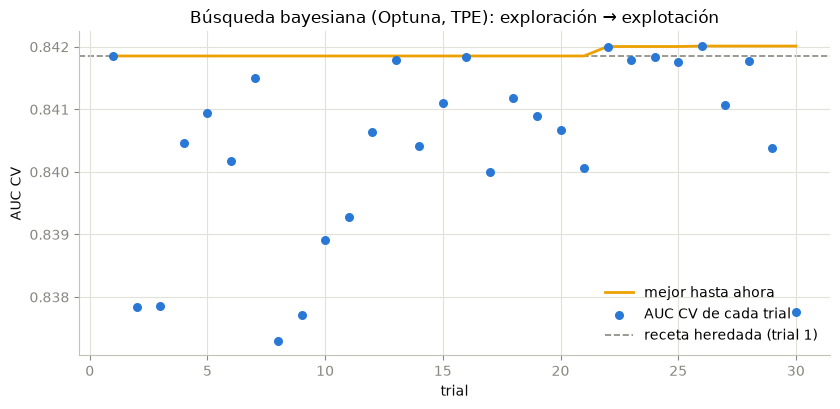

In [17]:
vals = [t.value for t in study.trials]
best_acum = np.maximum.accumulate(vals)
nums = np.arange(1, len(vals) + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(nums, best_acum, color=C_AMARILLO, lw=2, label="mejor hasta ahora", zorder=2)
ax.scatter(nums, vals, color=C_AZUL, s=30, label="AUC CV de cada trial", zorder=3)
ax.axhline(vals[0], color=C_MUTED, ls="--", lw=1.2, label="receta heredada (trial 1)", zorder=1)
ax.set_xlabel("trial")
ax.set_ylabel("AUC CV")
ax.set_title("Búsqueda bayesiana (Optuna, TPE): exploración → explotación")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

**Resultado: Optuna encontró una receta apenas mejor — AUC CV 0.8420 vs. 0.8419 de la heredada sobre este feature set (+0.0002), en 19.6 min.** El ganador (trial 26): `max_depth=7, eta=0.030, min_child_weight=2, subsample=0.80, colsample_bytree=0.79, gamma=0.84`. Las dos sanidades funcionaron: el trial 1 (la receta heredada encolada) reprodujo exacto el 0.8419 del cierre del Bloque B, y el patrón exploración→explotación es visible en el gráfico — primeros ~10 trials dispersos, después la nube se concentra.

La lectura de la "tablita" vale más que el punto ganador: **todos los trials de 0.8418 para arriba comparten la misma zona** — profundidad 6–7 (un 8 suelto), `eta` en 0.030–0.042 con ~200–350 rondas (la relación eta chico ↔ más árboles, de nuevo), `min_child_weight` chico (1–4), y `gamma` repartido entre 0.2 y 1.5 — lejos del 0 fijo que veníamos heredando del árbol de la Clase 3, aunque sin una dirección nítida adentro del rango. Esa es la lectura que el profesor recomienda para acotar búsquedas futuras.

Dos honestidades para cerrar: **(1)** la ganancia del tuneo es chica, tal cual anticipó la clase para un dataset ya afinado — el salto de esta clase vino de las features (+0.0051) contra +0.0002 del tuneo: la relación ~25:1 es el resumen perfecto de "el margen está en la información, no en los hiperparámetros". **(2)** `eta=0.030` quedó exactamente en el borde inferior del rango buscado — la misma alerta de borde que motivó el mini-refinamiento de la Clase 4. No lo perseguimos ahora: con eta más chico las rondas crecen hacia el tope de 600 y la ganancia marginal viene decayendo; queda anotado como refinamiento posible para el cierre pre-entrega.

### Ventana de datos, cuarta pasada

La ventana de 24 meses se eligió en la Clase 2 (árbol), se re-validó dos veces en la Clase 4 (al migrar a XGBoost y al cierre) — pero este notebook cambió las condiciones otra vez: hay features nuevas de **naturaleza distinta**. Los patrones de comportamiento envejecen (el gusto cambia — por eso ganaban los 24 meses), pero la metadata de una canción es estática: la duración de un tema no caduca. Con parte de la señal ahora "eterna", la ventana óptima podría alargarse. Re-testeamos {12, 24, 36, toda la historia} con la receta y el feature set finales. Sanidad: la fila de 24 meses debe reproducir el AUC del cierre del Bloque C (misma configuración, misma semilla).

In [18]:
log_progreso("=== Re-test de ventana (receta y feature set finales) ===")
resultados_v = []
for ventana in [12, 24, 36, None]:
    etiqueta = "toda la historia" if ventana is None else f"{ventana} meses"
    auc, _, rondas, _ = evaluar_cv(CAT_FINAL_5, NUM_FINAL_5, RECETA_5, ventana=ventana,
                                   etiqueta=f"ventana {etiqueta}")
    resultados_v.append({"ventana": etiqueta, "meses": ventana, "auc_cv": auc, "rondas": rondas})

res_v = pd.DataFrame(resultados_v).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\n" + res_v[["ventana", "auc_cv"]].round(4).to_string(index=False))

VENTANA_5 = res_v.loc[0, "meses"]
VENTANA_5 = None if pd.isna(VENTANA_5) else int(VENTANA_5)
AUC_CIERRE_CV = float(res_v.loc[0, "auc_cv"])
NROUNDS_5 = int(round(float(res_v.loc[0, "rondas"])))

fila_24 = res_v[res_v["meses"] == 24]["auc_cv"].iloc[0]
log_progreso(f"sanidad: 24 meses reproduce el cierre del Bloque C? {fila_24:.4f} vs. {AUC_CIERRE_C:.4f}")
etiqueta_v5 = "toda la historia" if VENTANA_5 is None else f"{VENTANA_5} meses"
log_progreso(f"decision de ventana: {etiqueta_v5} -> AUC CV de cierre {AUC_CIERRE_CV:.4f} | NROUNDS_5={NROUNDS_5}")

[20:22:44] === Re-test de ventana (receta y feature set finales) ===
[20:23:26] ventana 12 meses                                     -> AUC CV 0.8400 | folds [0.7871 0.8426 0.8897 0.8406] | rondas prom 262 |   42s
[20:24:25] ventana 24 meses                                     -> AUC CV 0.8420 | folds [0.7872 0.8428 0.8915 0.8465] | rondas prom 330 |   60s
[20:25:41] ventana 36 meses                                     -> AUC CV 0.8415 | folds [0.7869 0.8434 0.8886 0.8471] | rondas prom 382 |   75s
[20:27:17] ventana toda la historia                             -> AUC CV 0.8410 | folds [0.7871 0.8419 0.8898 0.8452] | rondas prom 402 |   96s

         ventana  auc_cv
        24 meses  0.8420
        36 meses  0.8415
toda la historia  0.8410
        12 meses  0.8400
[20:27:17] sanidad: 24 meses reproduce el cierre del Bloque C? 0.8420 vs. 0.8420
[20:27:17] decision de ventana: 24 meses -> AUC CV de cierre 0.8420 | NROUNDS_5=330


### Comparación final honesta en `test_interno` (única mirada)

Todas las decisiones de esta clase quedaron cerradas mirando solo `train` vía CV temporal: features de la API (Bloque A), cluster como atributo (Bloque B), hiperparámetros (Bloque C), cantidad de árboles (`NROUNDS_5`, las rondas promedio del ganador en la CV de la ventana elegida) y ventana. `test_interno` no se tocó en ningún experimento de arriba. Ahora sí, una única vez, con el **protocolo reforzado de la Clase 4**: rondas fijadas de antemano por la CV, **sin early stopping contra `test_interno`** (el watchlist muestra la curva mientras entrena, pero no decide nada), matriz construida una sola vez sobre la unión y partida por posición. La vara: **0.8247** de la Clase 4 sobre el mismo `test_interno`.

In [19]:
df_train_final = filtrar_reciente(df_train, VENTANA_5)
df_ambos = pd.concat([df_train_final, df_test_interno])

X_ambos, y_ambos, names_ambos = build_sparse_matrix(df_ambos, CAT_FINAL_5, NUM_FINAL_5)
n_tr = len(df_train_final)
dtr_final = xgb.DMatrix(X_ambos[:n_tr], label=y_ambos[:n_tr], feature_names=names_ambos)
dte_final = xgb.DMatrix(X_ambos[n_tr:], label=y_ambos[n_tr:], feature_names=names_ambos)

booster_final = xgb.train(
    {**BASE_PARAMS_XGB, **RECETA_5}, dtr_final,
    num_boost_round=NROUNDS_5,
    evals=[(dtr_final, "train"), (dte_final, "test_interno")],
    verbose_eval=50,
)

pred_test = booster_final.predict(dte_final)
auc_test5 = roc_auc_score(y_ambos[n_tr:], pred_test)

print(f"\nRondas fijadas por la CV (NROUNDS_5): {NROUNDS_5}")
print(f"AUC test_interno -- XGBoost Clase 4:          {AUC_CLASE4_TEST:.4f}")
print(f"AUC test_interno -- Clase 5 (API+cluster+opt): {auc_test5:.4f}")
print(f"Mejora:                                        {auc_test5 - AUC_CLASE4_TEST:+.4f}")
log_progreso(f"TEST_INTERNO (unica mirada): Clase 5 {auc_test5:.4f} vs. Clase 4 {AUC_CLASE4_TEST:.4f} "
             f"({auc_test5 - AUC_CLASE4_TEST:+.4f})")

[0]	train-auc:0.83438	test_interno-auc:0.79805
[50]	train-auc:0.85739	test_interno-auc:0.83000
[100]	train-auc:0.86378	test_interno-auc:0.83360
[150]	train-auc:0.86919	test_interno-auc:0.83538
[200]	train-auc:0.87269	test_interno-auc:0.83653
[250]	train-auc:0.87531	test_interno-auc:0.83698
[300]	train-auc:0.87777	test_interno-auc:0.83752
[329]	train-auc:0.87895	test_interno-auc:0.83772

Rondas fijadas por la CV (NROUNDS_5): 330
AUC test_interno -- XGBoost Clase 4:          0.8247
AUC test_interno -- Clase 5 (API+cluster+opt): 0.8377
Mejora:                                        +0.0130
[20:27:42] TEST_INTERNO (unica mirada): Clase 5 0.8377 vs. Clase 4 0.8247 (+0.0130)


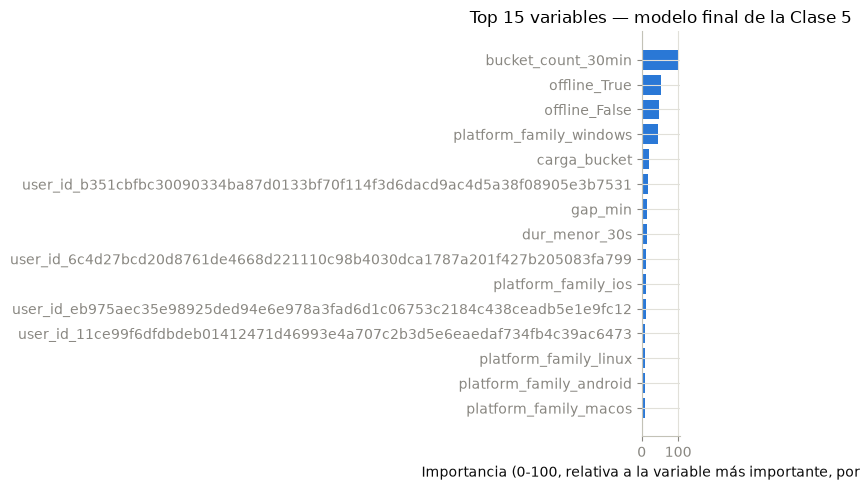

Variables usadas por el modelo: 97 de 136 columnas
Features nuevas de esta clase dentro del top 15: ['carga_bucket', 'dur_menor_30s']


In [20]:
importancias = booster_final.get_score(importance_type="gain")
imp_df = pd.DataFrame(list(importancias.items()), columns=["feature", "gain"]).sort_values("gain", ascending=False)
imp_df["gain_norm"] = 100 * imp_df["gain"] / imp_df["gain"].max()

top_n = 15
top_imp = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["gain_norm"], color=C_AZUL)
plt.xlabel("Importancia (0-100, relativa a la variable más importante, por gain)")
plt.title(f"Top {top_n} variables — modelo final de la Clase 5")
plt.tight_layout()
plt.show()

nuevas = [f for f in imp_df["feature"].head(top_n) if f in
          ["duracion_ms", "dur_menor_30s", "carga_bucket", "popularity", "antiguedad_dias",
           "explicit_num", "track_number", "album_total_tracks"] or f.startswith("track_cluster")]
print(f"Variables usadas por el modelo: {len(imp_df)} de {len(names_ambos)} columnas")
print(f"Features nuevas de esta clase dentro del top {top_n}: {nuevas}")

### Modelo final: reentrenar con el 100% de los datos y submission

Misma práctica de siempre: el modelo de Kaggle se reentrena con el 100% de las filas de train (filtradas a `VENTANA_5`), con `NROUNDS_5` rondas fijadas por la CV — nada depende de `test_interno`. Detalles de correctitud, los heredados y los nuevos de esta clase:

- **`gap_min`**: continuidad real train→test (la primera fila de cada usuario en test necesita el historial que quedó en train). **`bucket_count_30min`/`pos_en_bucket`/`bucket_count_dia`**: autocontenidos (el corte train/test cae en cambio de día calendario). **`gap_siguiente`**: autocontenido en test, sin puente hacia train (razonamiento en la Clase 4).
- **Features de la API** (nuevo): el join es por URI contra una tabla estática — exactamente las mismas columnas y el mismo helper que en train; sin ninguna dependencia temporal, no hay nada que puentear.
- **`track_cluster`** (nuevo, si quedó adoptado): las canciones del test se asignan con `predict` sobre los centroides, el scaler y las medianas de imputación aprendidos **solo de las canciones de `df_train`** — nada del test entra a ningún fit. Canciones sin metadata → `sin_api`, la misma categoría que ya existe en train.

In [21]:
train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
train_final_full = filtrar_reciente(train_completo, VENTANA_5)

test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False,
)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = test_raw["ts_dt"].dt.hour
test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

# gap_min: recencia con continuidad real train->test (unica feature que la necesita)
combinado = pd.concat([
    train_completo[["obs_id", "user_id", "ts_dt"]],
    test_raw[["obs_id", "user_id", "ts_dt"]],
]).sort_values(["ts_dt", "obs_id"])
combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
gap_por_obs = combinado.set_index("obs_id")["gap_min"]
test_raw["gap_min"] = test_raw["obs_id"].map(gap_por_obs).fillna(-1)

# el resto de los conteos, autocontenidos en test
test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")
test_raw["pos_en_bucket"] = test_raw.groupby(["user_id", "ts"]).cumcount()
fecha_test = test_raw["ts_dt"].dt.floor("D")
test_raw["bucket_count_dia"] = test_raw.groupby(["user_id", fecha_test])["obs_id"].transform("size")
gap_sig_test = (test_raw.groupby("user_id")["ts_dt"].shift(-1) - test_raw["ts_dt"]).dt.total_seconds() / 60.0
test_raw["gap_siguiente"] = gap_sig_test.fillna(-1)

# API y cluster: mismos helpers/mapas aprendidos de train (bucket_count ya calculado arriba,
# que carga_bucket lo necesita)
test_raw = agregar_columnas_api(test_raw)
for k in (5, 10):
    test_raw[f"track_cluster{k}"] = test_raw["uri"].map(CLUSTER_MAPS[k]).fillna("sin_api")
log_progreso(f"test de Kaggle preparado: {len(test_raw):,} filas | cobertura API {test_raw['duracion_ms'].notna().mean():.1%}")

# Matriz sobre la union (categorias = metadata estructural, mismo argumento de siempre),
# partida por posicion. El "target" NaN del lado test nunca se usa.
df_ambos_kaggle = pd.concat([train_final_full, test_raw])
X_ak, y_ak, names_ak = build_sparse_matrix(df_ambos_kaggle, CAT_FINAL_5, NUM_FINAL_5)
n_tr_k = len(train_final_full)

dtrain_kaggle = xgb.DMatrix(X_ak[:n_tr_k], label=y_ak[:n_tr_k], feature_names=names_ak)
dtest_kaggle = xgb.DMatrix(X_ak[n_tr_k:], feature_names=names_ak)

modelo_final = xgb.train({**BASE_PARAMS_XGB, **RECETA_5}, dtrain_kaggle, num_boost_round=NROUNDS_5)
test_pred = modelo_final.predict(dtest_kaggle)

submission = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": test_pred})
submission.to_csv("../submissions/06_submission_clase5_api_optuna.csv", index=False)
print(f"Guardado 06_submission_clase5_api_optuna.csv -- {len(submission)} filas | "
      f"probs en [{test_pred.min():.4f}, {test_pred.max():.4f}], media {test_pred.mean():.4f}")

etiqueta_v5 = "toda la historia" if VENTANA_5 is None else f"{VENTANA_5} meses"
log_progreso(f"submission guardada: 06_submission_clase5_api_optuna.csv ({len(submission)} filas, "
             f"{NROUNDS_5} rondas, train {n_tr_k:,} filas a {etiqueta_v5})")
log_progreso(f"RESUMEN FINAL Clase 5: AUC CV {AUC_CIERRE_CV:.4f} (Clase 4: {AUC_CLASE4_CV:.4f}, {AUC_CIERRE_CV - AUC_CLASE4_CV:+.4f}) | "
             f"test_interno {auc_test5:.4f} (Clase 4: {AUC_CLASE4_TEST:.4f}, {auc_test5 - AUC_CLASE4_TEST:+.4f}) | "
             f"receta {RECETA_5} | ventana {etiqueta_v5}")
submission.head()

[20:27:44] test de Kaggle preparado: 51,570 filas | cobertura API 100.0%
Guardado 06_submission_clase5_api_optuna.csv -- 51570 filas | probs en [0.0056, 0.9955], media 0.2577
[20:27:52] submission guardada: 06_submission_clase5_api_optuna.csv (51570 filas, 330 rondas, train 218,339 filas a 24 meses)
[20:27:52] RESUMEN FINAL Clase 5: AUC CV 0.8420 (Clase 4: 0.8368, +0.0052) | test_interno 0.8377 (Clase 4: 0.8247, +0.0130) | receta {'max_depth': 7, 'eta': 0.030223664895420776, 'min_child_weight': 2, 'subsample': 0.7963585977878456, 'colsample_bytree': 0.79208902443077, 'gamma': 0.8414960952850874} | ventana 24 meses


,obs_id,target
0,911345,0.186277
1,911346,0.092670
2,911347,0.035789
3,911348,0.029428
4,911349,0.032057


### Notas honestas para el informe — Clase 5 (con los números de la corrida ejecutada)

- **Qué se agregó respecto de la Clase 4:** features de la API de Spotify (Bloque A, protocolo acumulativo una-decisión-un-número sobre la misma CV temporal), clustering aplicado (Bloque B: perfiles horarios + dendrograma de usuarios como EDA, y K-means de canciones como atributo decidido por la CV), y búsqueda bayesiana de hiperparámetros con Optuna en lugar de grillas (Bloque C: TPE, 30 trials, receta heredada encolada como piso). Corrida completa: ~31 min (`06_progreso_clase5.log`); la sanidad inicial reprodujo el 0.8368 de la Clase 4 exacto antes de tocar nada.
- **Bloque A — los cinco grupos adoptados, AUC CV 0.8368 → 0.8419 (+0.0051):** `duracion_ms` +0.0034 (sola vale dos tercios del bloque, más que todo el tuneo de la Clase 4 junto), mecánicas `dur_menor_30s`+`carga_bucket` +0.0003, `popularity` +0.0004, `antiguedad_dias` +0.0006, metadata menor +0.0004. `carga_bucket` y `dur_menor_30s` entraron al top-15 de importancias del modelo final.
- **Bloque B — cluster rechazado con evidencia (K=5 −0.0001, K=10 −0.0002):** las numéricas crudas ya llevan esa información al modelo. Queda para el informe: el "pinchazo" aritmético del jerárquico a escala TP (774.642 filas → 3.0×10¹¹ distancias ≈ 2.4 TB de RAM), el dendrograma exacto de los 10 usuarios (la misma herramienta, aplicada donde N la permite), y la interpretación K=5 (separan `popularity` y `explicit`; micro-cluster de 85 ítems con metadata rota aislado solo — clustering como detector de anomalías).
- **Bloque C — Optuna +0.0002 (0.8420, trial 26: `depth=7, eta=0.030, mcw=2, sub=0.80, col=0.79, gamma=0.84`; 19.6 min):** zona ganadora consistente (depth 6–7, eta 0.03–0.04 con ~200–350 rondas, mcw 1–4, gamma > 0 — re-litigado tras tres clases fijo en 0); sanidad del trial 1 = 0.8419 exacto. Features contra tuneo ~25:1, tal cual anticipó la clase. `eta` en el borde inferior del rango: anotado para el cierre pre-entrega, no perseguido ahora.
- **Ventana re-validada (cuarta pasada): 24 meses (0.8420) contra 12 (0.8400), 36 (0.8415) y toda la historia (0.8410).** La hipótesis de que la metadata estática alargaría la ventana óptima no se confirmó: 36 meses quedó cerca (−0.0005) pero no superó. `NROUNDS_5 = 330` (rondas promedio del ganador en la CV de la ventana elegida).
- **`test_interno` (única mirada, rondas fijadas por la CV, sin early stopping adaptativo): 0.8377 vs. 0.8247 de la Clase 4 (+0.0130).** Dato interesante: la brecha CV→test_interno se achicó de ~−0.012/−0.014 (Clases 3–4) a −0.0043. Una lectura posible (hipótesis, no demostrada): la metadata estática de canciones envejece mejor que los patrones de comportamiento, y el período del test interno la aprovecha más que el promedio de la CV.
- **Matices honestos:** la metadata de la API es la *actual*, no la histórica — "duración<30s ⇒ target=1" da 93.2% en 2.040 filas, no ~100% (remasters/re-releases), y hay 0.02% de antigüedades negativas (release posterior a la escucha) que se dejan porque son información. `dur_menor_30s`/`carga_bucket` son señal estructural de la definición del target (familia de `bucket_count_30min`, "un poco de trampa, pero sirve"). El cluster de usuarios no se evaluó como feature por redundancia estructural con `user_id` one-hot (10 categorías ya dan flexibilidad total por usuario).
- **Submission:** `06_submission_clase5_api_optuna.csv` (51.570 filas; modelo reentrenado con el 100% de train filtrado a 24 meses = 218.339 filas, 330 rondas; cobertura de la API en el test real: 100.0%). **Score público en Kaggle: 0.84993** (vs. 0.84541 de la Clase 4, **+0.0045** — nuestro mejor score). La expectativa previa (~0.85–0.86) extrapolaba la brecha test_interno→Kaggle de ~+0.02 de las Clases 3–4; esta vez fue +0.0122. La lectura honesta: **el delta en Kaggle (+0.0045) coincide casi exacto con el delta de la CV (+0.0052)** — la CV volvió a ser la brújula correcta para las mejoras — mientras que `test_interno` lo sobreestimó (+0.0130). La brecha de +0.02 no era una constante: era en buena parte el bonus de que el modelo final entrena hasta ago-2024 (pegado al test real) y la medición interna solo hasta may-2023 — un bonus que amplifica las señales de comportamiento reciente, no a la metadata estática, que viaja pareja. Coherente con eso, la brecha CV→Kaggle viene siendo estable entre clases (+0.0057 / +0.0086 / +0.0079).